# Компьютерная работа №1  
## Многомерные статистические методы  
### Анализ цветовой интенсивности вина по химическим характеристикам

В работе используется массив `Wine` из `sklearn`, содержащий 178 независимых наблюдений и набор непрерывных лабораторных характеристик вина. В качестве зависимой переменной рассматривается показатель цветовой интенсивности.

$$
y = \text{color\_intensity}
$$

В качестве объясняющих переменных используются следующие признаки:

$$
x_1 = \text{alcohol},\quad
x_2 = \text{malic\_acid},\quad
x_3 = \text{flavanoids},\quad
x_4 = \text{hue},\quad
x_5 = \text{od280},\quad
x_6 = \text{proline}
$$

Для краткости далее используется обозначение `od280` вместо полного имени `od280/od315_of_diluted_wines`.

Дальнейший анализ построен последовательно: сначала рассматриваются распределение зависимой переменной и наличие выбросов, затем изучается корреляционная структура, после чего сравниваются линейная и степенная регрессионные модели. Такой порядок позволяет перейти от описания данных к содержательной интерпретации полученных зависимостей.


In [1]:

import pandas as pd
import numpy as np
import math
from itertools import combinations
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, shapiro, jarque_bera, normaltest, t, norm
import statsmodels.api as sm
from sklearn.datasets import load_wine
from IPython.display import display

plt.rcParams['figure.figsize'] = (8, 5)

raw = load_wine(as_frame=True).frame.copy()
raw = raw.rename(columns={'od280/od315_of_diluted_wines':'od280'})

y_col = 'color_intensity'
xs = ['alcohol', 'malic_acid', 'flavanoids', 'hue', 'od280', 'proline']
cols = [y_col] + xs

df = raw[cols].copy()

roles = pd.DataFrame({
    'Роль': ['Зависимая'] + ['Фактор'] * len(xs),
    'Переменная': [y_col] + xs,
    'Смысл': [
        'Цветовая интенсивность',
        'Содержание алкоголя',
        'Яблочная кислота',
        'Флаваноиды',
        'Оттенок',
        'Оптическая плотность OD280/OD315',
        'Пролин'
    ],
    'Группа': [
        'Целевой признак',
        'Базовый химический профиль',
        'Базовый химический профиль',
        'Фенольный блок',
        'Оптический блок',
        'Фенольный блок',
        'Экстрактивность'
    ]
})

display(roles)
pd.DataFrame({'n': [len(df)], 'Число пропусков': [int(df.isna().sum().sum())]})


,Роль,Переменная,Смысл,Группа
0,Зависимая,color_intensity,Цветовая интенсивность,Целевой признак
1,Фактор,alcohol,Содержание алкоголя,Базовый химический профиль
2,Фактор,malic_acid,Яблочная кислота,Базовый химический профиль
3,Фактор,flavanoids,Флаваноиды,Фенольный блок
4,Фактор,hue,Оттенок,Оптический блок
5,Фактор,od280,Оптическая плотность OD280/OD315,Фенольный блок
6,Фактор,proline,Пролин,Экстрактивность


,n,Число пропусков
0,178,0


## 1. Постановка задачи и гипотезы

Выбранная выборка удовлетворяет формальным требованиям задания: число наблюдений составляет **178 > 60**, используется **7 непрерывных переменных**, пропуски отсутствуют.

Содержательно набор данных также удобен для анализа. Все признаки представляют собой лабораторные измерения, поэтому их можно сопоставлять в рамках одной предметной логики без смешения количественных и категориальных шкал. Диапазоны значений достаточно широкие, что делает задачу моделирования содержательно обоснованной.

Факторы условно разделяются на несколько блоков:

- базовый химический профиль: `alcohol`, `malic_acid`
- фенольный блок: `flavanoids`, `od280`
- оптический блок: `hue`
- экстрактивность: `proline`

Рабочие гипотезы формулируются следующим образом:

1. Более высокие значения `alcohol` и `proline` должны сопровождаться ростом `color_intensity`.
2. Увеличение `hue` и `od280` должно быть связано со снижением `color_intensity`.
3. Связь `malic_acid` с целевой переменной, вероятно, окажется слабее и может исчезнуть после учёта остальных факторов.
4. Верхнехвостовые выбросы по `color_intensity` могут искажать парные связи, поэтому после очистки структура зависимостей должна стать устойчивее.


## 2. Основные характеристики зависимой переменной

Для `color_intensity` рассчитываются стандартные показатели положения и разброса:

$$
\bar y = \frac{1}{n}\sum_{i=1}^n y_i,\qquad
s^2 = \frac{1}{n-1}\sum_{i=1}^n (y_i-\bar y)^2,\qquad
CV = \frac{s}{\bar y}\cdot 100\%
$$

Дополнительно приводятся квартильные и децильные характеристики. Такой набор показателей позволяет оценить не только средний уровень признака, но и форму его распределения, что особенно важно при отсутствии оснований заранее предполагать симметрию.


In [2]:

tt = df[y_col]

desc = pd.DataFrame({
    'Показатель': ['Среднее', 'Медиана', 'Мода', 'Минимум', 'Максимум', 'Размах', 'Дисперсия', 'Стандартное отклонение', 'Коэффициент вариации, %'],
    'Значение': [
        tt.mean(),
        tt.median(),
        '; '.join([str(v).rstrip('0').rstrip('.') for v in tt.mode().round(2).tolist()]),
        tt.min(),
        tt.max(),
        tt.max() - tt.min(),
        tt.var(ddof=1),
        tt.std(ddof=1),
        tt.std(ddof=1) / tt.mean() * 100
    ]
})

ranks = pd.DataFrame({
    'Показатель': ['Q1', 'Q2', 'Q3', 'IQR', 'D1', 'D9'],
    'Значение': [
        tt.quantile(0.25),
        tt.quantile(0.50),
        tt.quantile(0.75),
        tt.quantile(0.75) - tt.quantile(0.25),
        tt.quantile(0.10),
        tt.quantile(0.90)
    ]
})

display(desc.round(4))
display(ranks.round(4))


,Показатель,Значение
0,Среднее,5.05809
1,Медиана,4.69
2,Мода,2.6; 3.8; 4.6
3,Минимум,1.28
4,Максимум,13.0
5,Размах,11.72
6,Дисперсия,5.374449
7,Стандартное отклонение,2.318286
8,"Коэффициент вариации, %",45.833228


,Показатель,Значение
0,Q1,3.220
1,Q2,4.690
2,Q3,6.200
3,IQR,2.980
4,D1,2.549
5,D9,8.530


Среднее значение признака составляет **5.058**, медиана — **4.690**. Превышение среднего над медианой указывает на наличие правостороннего смещения распределения.

Коэффициент вариации равен **45.83\%**, поэтому разброс нельзя считать малым. Для последующего моделирования это важно: зависимая переменная обладает достаточной изменчивостью, и различия между наблюдениями носят содержательный, а не случайный характер.

Мода оказалась множественной. Для лабораторных данных такая ситуация естественна, поскольку часть значений повторяется из-за округления, а сама совокупность может быть неоднородной по составу.


## 3. Диагностика выбросов

Для диагностики выбросов используются три практических правила:

$$
IQR = Q_3 - Q_1
$$

$$
y < Q_1 - 1.5\,IQR \quad \text{или} \quad y > Q_3 + 1.5\,IQR
$$

$$
y < Q_1 - 3\,IQR \quad \text{или} \quad y > Q_3 + 3\,IQR
$$

$$
|y-\bar y| > 3s
$$

Дополнительно рассматриваются формальный критерий Граббса и обобщённый ESD-тест Рознера. Важно оценить не только наличие экстремальных наблюдений как таковых, но и то, насколько они способны повлиять на корреляционный и регрессионный анализ.


,Правило,Нижняя граница,Верхняя граница,Число наблюдений
0,1.5IQR,-1.2500,10.6700,4
1,3IQR,-5.7200,15.1400,0
2,3σ,-1.8968,12.0129,1


,Метод,Наблюдение,Значение y
0,1.5IQR,152,10.80
1,1.5IQR,159,13.00
2,1.5IQR,160,11.75
3,1.5IQR,167,10.68
4,3σ,159,13.00


,G,G_crit,obs,value,is_outlier
0,3.4258,3.5702,159,13.0,False


,i,Наблюдение,Значение,R_i,lambda_i,R_i > lambda_i,Подтверждён выброс
0,1,159,13.00,3.4258,3.5702,False,False
1,2,160,11.75,2.9994,3.5685,False,False
2,3,152,10.80,2.6553,3.5667,False,False
3,4,167,10.68,2.6628,3.5650,False,False
4,5,154,10.52,2.6512,3.5632,False,False
5,6,168,10.26,2.5898,3.5614,False,False
6,7,176,10.20,2.6204,3.5597,False,False
7,8,172,9.90,2.5333,3.5579,False,False
8,9,173,9.70,2.4891,3.5561,False,False
9,10,165,9.58,2.4821,3.5542,False,False


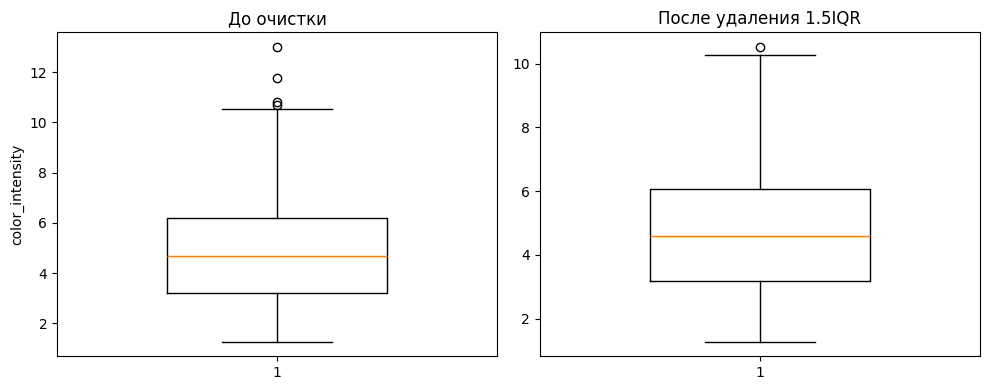

In [3]:

def grubbs_test(x, alpha=0.05):
    s = pd.Series(x).dropna().astype(float)
    n = len(s)
    mu = s.mean()
    sd = s.std(ddof=1)
    z = ((s - mu).abs() / sd)
    G = z.max()
    idx = z.idxmax()
    tcrit = t.ppf(1 - alpha / (2 * n), n - 2)
    Gcrit = ((n - 1) / np.sqrt(n)) * np.sqrt(tcrit**2 / (n - 2 + tcrit**2))
    return {'G': G, 'G_crit': Gcrit, 'obs': int(idx) + 1, 'value': s.loc[idx], 'is_outlier': G > Gcrit}

def rosner_esd(x, k=10, alpha=0.05):
    s = pd.Series(x).dropna().astype(float)
    n = len(s)
    k = min(k, n - 2)
    w = s.copy()
    rows = []
    m = 0
    for i in range(1, k + 1):
        mu = w.mean()
        sd = w.std(ddof=1)
        d = (w - mu).abs()
        idx = d.idxmax()
        Ri = d.loc[idx] / sd
        ni = n - i + 1
        p = 1 - alpha / (2 * ni)
        tcrit = t.ppf(p, ni - 2)
        lam = (ni - 1) * tcrit / np.sqrt(ni * (ni - 2 + tcrit**2))
        rows.append({
            'i': i,
            'Наблюдение': int(idx) + 1,
            'Значение': float(w.loc[idx]),
            'R_i': float(Ri),
            'lambda_i': float(lam),
            'R_i > lambda_i': bool(Ri > lam)
        })
        if Ri > lam:
            m = i
        w = w.drop(index=idx)
    tab = pd.DataFrame(rows)
    tab['Подтверждён выброс'] = False
    if m > 0:
        tab.loc[:m-1, 'Подтверждён выброс'] = True
    return tab

tt = df[y_col]
q1, q3 = tt.quantile([0.25, 0.75])
iqr = q3 - q1
b1 = q1 - 1.5 * iqr
b2 = q3 + 1.5 * iqr
b3 = q1 - 3 * iqr
b4 = q3 + 3 * iqr
b5 = tt.mean() - 3 * tt.std(ddof=1)
b6 = tt.mean() + 3 * tt.std(ddof=1)

bad_iqr = tt[(tt < b1) | (tt > b2)]
bad_3iqr = tt[(tt < b3) | (tt > b4)]
bad_3s = tt[(tt < b5) | (tt > b6)]

rules = pd.DataFrame({
    'Правило': ['1.5IQR', '3IQR', '3σ'],
    'Нижняя граница': [b1, b3, b5],
    'Верхняя граница': [b2, b4, b6],
    'Число наблюдений': [len(bad_iqr), len(bad_3iqr), len(bad_3s)]
})

bad_rows = pd.concat([
    pd.DataFrame({'Метод': '1.5IQR', 'Наблюдение': bad_iqr.index + 1, 'Значение y': bad_iqr.values}),
    pd.DataFrame({'Метод': '3σ', 'Наблюдение': bad_3s.index + 1, 'Значение y': bad_3s.values})
], ignore_index=True)

g = grubbs_test(tt)
r = rosner_esd(tt, k=10, alpha=0.05)

display(rules.round(4))
display(bad_rows.round(4))
display(pd.DataFrame([g]).round(4))
display(r.head(10).round(4))

mask = (tt >= b1) & (tt <= b2)
clean = df[mask].copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(df[y_col], vert=True, widths=0.5)
ax[0].set_title('До очистки')
ax[0].set_ylabel(y_col)
ax[1].boxplot(clean[y_col], vert=True, widths=0.5)
ax[1].set_title('После удаления 1.5IQR')
plt.tight_layout()
plt.show()


Проверка показала, что по правилу **1.5IQR** выделяются **4** верхних наблюдения: 152, 159, 160 и 167. По правилу **3σ** фиксируется только одно экстремальное значение, а по правилу **3IQR** выбросы не обнаруживаются.

Формальные критерии Граббса и Рознера на уровне значимости 0.05 наличие выбросов не подтвердили. Это означает, что верхний хвост действительно выражен, однако степень его отклонения недостаточна для того, чтобы рассматривать соответствующие наблюдения как статистически аномальные в строгом смысле.

Для дальнейшего корреляционного и регрессионного анализа используется очищенная выборка по правилу **1.5IQR**. В данном случае это решение оправдано: правило хорошо отделяет верхний хвост и позволяет оценить устойчивость результатов без заметного искажения общей структуры данных. После очистки в выборке остаётся **174** наблюдения.


## 4. Проверка распределения зависимой переменной на нормальность

На первом шаге оцениваются моментные характеристики распределения:

$$
A = \frac{\mu_3}{s^3},\qquad
E = \frac{\mu_4}{s^4} - 3
$$

Затем используются графические методы и статистические критерии нормальности. Если бы распределение было близко к нормальному, асимметрия и эксцесс должны были бы находиться вблизи нуля, а соответствующие p-value не давали бы оснований отвергать нулевую гипотезу.


,Показатель,Значение
0,Асимметрия,0.868585
1,Эксцесс,0.381522
2,Shapiro-Wilk p-value,0.000001
3,D’Agostino-Pearson p-value,0.000053
4,Jarque-Bera p-value,0.000011


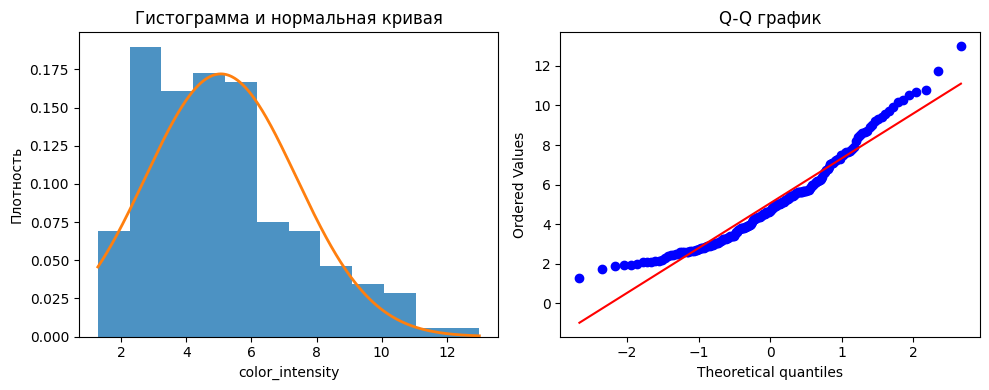

In [4]:

tt = df[y_col]

norm_tab = pd.DataFrame({
    'Показатель': ['Асимметрия', 'Эксцесс', 'Shapiro-Wilk p-value', 'D’Agostino-Pearson p-value', 'Jarque-Bera p-value'],
    'Значение': [
        stats.skew(tt, bias=False),
        stats.kurtosis(tt, bias=False, fisher=True),
        shapiro(tt).pvalue,
        normaltest(tt).pvalue,
        jarque_bera(tt).pvalue
    ]
})

display(norm_tab.round(6))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(tt, bins='auto', density=True, alpha=0.8)
xx = np.linspace(tt.min(), tt.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, tt.mean(), tt.std(ddof=1)), linewidth=2)
ax[0].set_title('Гистограмма и нормальная кривая')
ax[0].set_xlabel(y_col)
ax[0].set_ylabel('Плотность')
stats.probplot(tt, dist='norm', plot=ax[1])
ax[1].set_title('Q-Q график')
plt.tight_layout()
plt.show()


Для переменной `color_intensity` характерна **правая асимметрия**: коэффициент асимметрии равен **0.869**. Эксцесс составляет **0.382** и сам по себе невелик, однако вместе с асимметрией указывает на отклонение от нормальной формы.

Все три критерия дают малые p-value:
- Shapiro-Wilk: **9.23e-07**
- D’Agostino-Pearson: **5.32e-05**
- Jarque-Bera: **1.09e-05**

Следовательно, гипотеза о нормальном распределении генеральной совокупности для `color_intensity` **отвергается**. Этот вывод согласуется и с графической диагностикой: правый хвост распределения длиннее, чем у нормального закона, а верхние точки на Q-Q графике заметно отклоняются вверх.


## 5. Корреляционный анализ

В этом разделе сначала рассматриваются три базовых типа связи на диаграммах рассеяния — положительная, отрицательная и практически отсутствующая. Затем строятся матрицы парных коэффициентов корреляции до и после удаления выбросов, а после этого анализ дополняется частными коэффициентами на очищенной выборке.


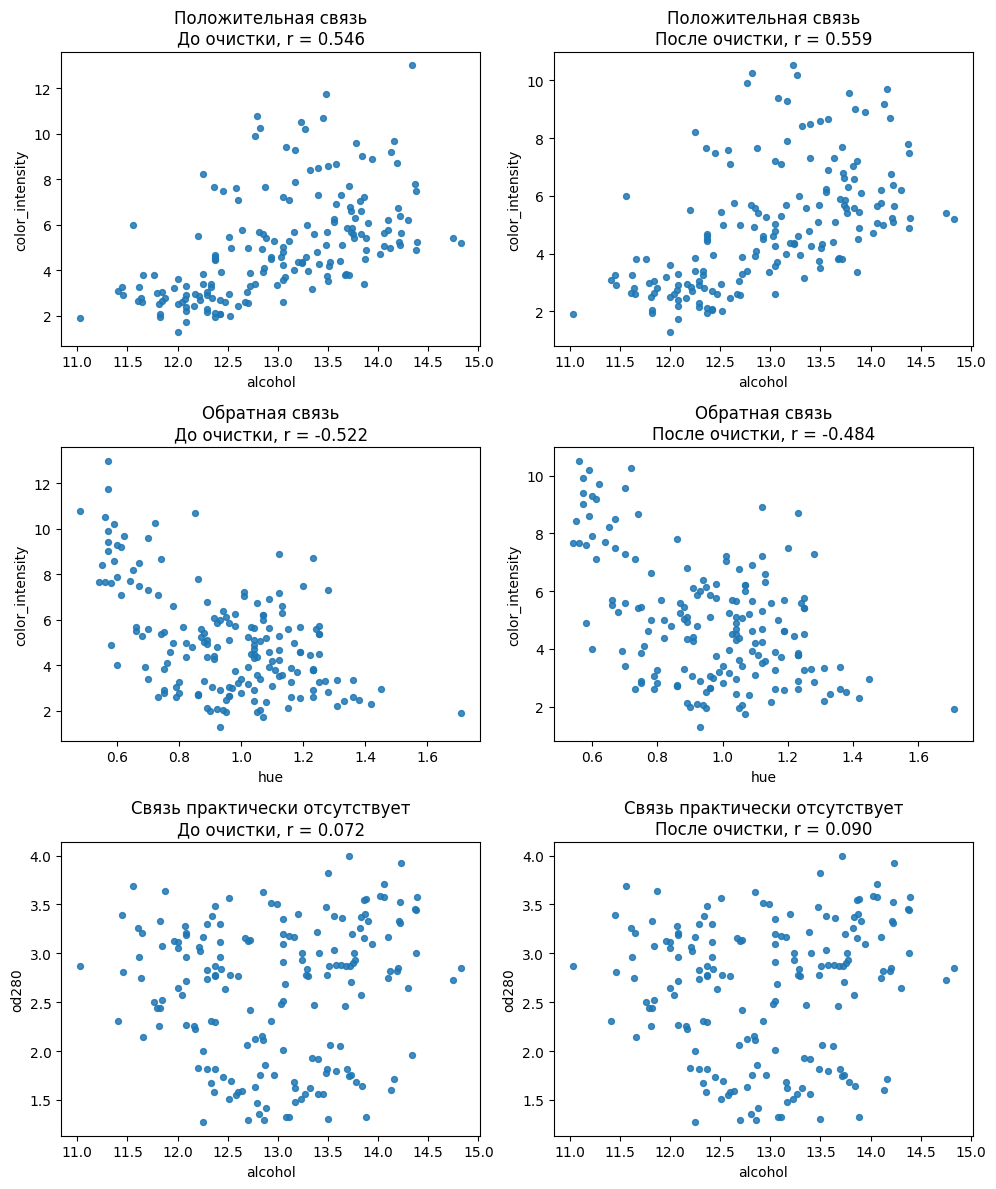

In [5]:

pairs = [
    ('alcohol', 'color_intensity', 'Положительная связь'),
    ('hue', 'color_intensity', 'Обратная связь'),
    ('alcohol', 'od280', 'Связь практически отсутствует')
]

fig, ax = plt.subplots(3, 2, figsize=(10, 12))
for i, (x, y, ttl) in enumerate(pairs):
    for j, (data, subttl) in enumerate([(df, 'До очистки'), (clean, 'После очистки')]):
        a = ax[i, j]
        a.scatter(data[x], data[y], s=18, alpha=0.85)
        rr = data[[x, y]].corr().iloc[0, 1]
        a.set_title(f'{ttl}\n{subttl}, r = {rr:.3f}')
        a.set_xlabel(x)
        a.set_ylabel(y)
plt.tight_layout()
plt.show()


,color_intensity,alcohol,malic_acid,flavanoids,hue,od280,proline
color_intensity,1.000,0.546***,0.249***,-0.172*,-0.522***,-0.429***,0.316***
alcohol,0.546***,1.000,0.094,0.237**,-0.072,0.072,0.644***
malic_acid,0.249***,0.094,1.000,-0.411***,-0.561***,-0.369***,-0.192*
flavanoids,-0.172*,0.237**,-0.411***,1.000,0.543***,0.787***,0.494***
hue,-0.522***,-0.072,-0.561***,0.543***,1.000,0.565***,0.236**
od280,-0.429***,0.072,-0.369***,0.787***,0.565***,1.000,0.313***
proline,0.316***,0.644***,-0.192*,0.494***,0.236**,0.313***,1.000


,color_intensity,alcohol,malic_acid,flavanoids,hue,od280,proline
color_intensity,1.000,0.559***,0.278***,-0.131,-0.484***,-0.393***,0.381***
alcohol,0.559***,1.000,0.100,0.254***,-0.054,0.090,0.655***
malic_acid,0.278***,0.100,1.000,-0.414***,-0.587***,-0.373***,-0.193*
flavanoids,-0.131,0.254***,-0.414***,1.000,0.537***,0.784***,0.492***
hue,-0.484***,-0.054,-0.587***,0.537***,1.000,0.549***,0.226**
od280,-0.393***,0.090,-0.373***,0.784***,0.549***,1.000,0.306***
proline,0.381***,0.655***,-0.193*,0.492***,0.226**,0.306***,1.000


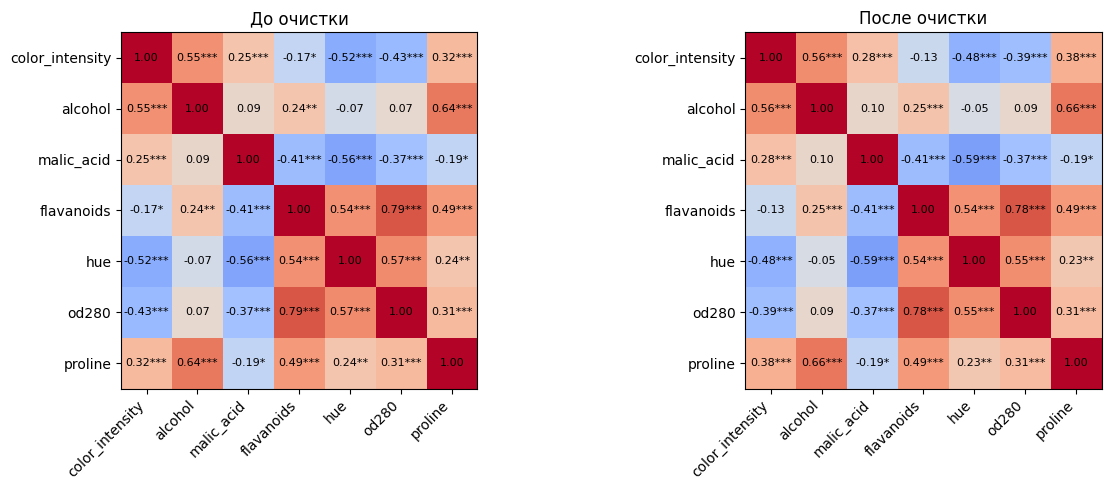

,color_intensity,alcohol,malic_acid,flavanoids,hue,od280,proline
color_intensity,0.000,0.013,0.029,0.041,0.038,0.036,0.065
alcohol,0.013,0.000,0.006,0.017,0.018,0.018,0.012
malic_acid,0.029,0.006,0.000,-0.003,-0.026,-0.004,-0.001
flavanoids,0.041,0.017,-0.003,0.000,-0.006,-0.003,-0.002
hue,0.038,0.018,-0.026,-0.006,0.000,-0.016,-0.010
od280,0.036,0.018,-0.004,-0.003,-0.016,0.000,-0.006
proline,0.065,0.012,-0.001,-0.002,-0.010,-0.006,0.000


In [6]:

def fisher_ci_r(r, n, alpha=0.05):
    if abs(r) >= 1:
        return r, r
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    zc = norm.ppf(1 - alpha / 2)
    return tuple(np.tanh([z - zc * se, z + zc * se]))

def pair_corr_with_p(data):
    cc = list(data.columns)
    r = pd.DataFrame(np.eye(len(cc)), index=cc, columns=cc, dtype=float)
    p = pd.DataFrame(np.zeros((len(cc), len(cc))), index=cc, columns=cc, dtype=float)
    for i in range(len(cc)):
        for j in range(i + 1, len(cc)):
            rr, pp = pearsonr(data.iloc[:, i], data.iloc[:, j])
            r.iloc[i, j] = r.iloc[j, i] = rr
            p.iloc[i, j] = p.iloc[j, i] = pp
    return r, p

def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def make_annot(r, p):
    out = r.copy().astype(object)
    for i in range(len(r)):
        for j in range(len(r.columns)):
            if i == j:
                out.iloc[i, j] = '1.000'
            else:
                out.iloc[i, j] = f'{r.iloc[i, j]:.3f}{sig_stars(p.iloc[i, j])}'
    return out

r0, p0 = pair_corr_with_p(df)
r1, p1 = pair_corr_with_p(clean)

display(make_annot(r0, p0))
display(make_annot(r1, p1))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im0 = ax[0].imshow(r0.values, vmin=-1, vmax=1, cmap='coolwarm')
ax[0].set_xticks(range(len(r0.columns)))
ax[0].set_yticks(range(len(r0.columns)))
ax[0].set_xticklabels(r0.columns, rotation=45, ha='right')
ax[0].set_yticklabels(r0.columns)
ax[0].set_title('До очистки')
for i in range(len(r0.columns)):
    for j in range(len(r0.columns)):
        txt = f'{r0.iloc[i, j]:.2f}'
        if i != j:
            txt += sig_stars(p0.iloc[i, j])
        ax[0].text(j, i, txt, ha='center', va='center', fontsize=8)

im1 = ax[1].imshow(r1.values, vmin=-1, vmax=1, cmap='coolwarm')
ax[1].set_xticks(range(len(r1.columns)))
ax[1].set_yticks(range(len(r1.columns)))
ax[1].set_xticklabels(r1.columns, rotation=45, ha='right')
ax[1].set_yticklabels(r1.columns)
ax[1].set_title('После очистки')
for i in range(len(r1.columns)):
    for j in range(len(r1.columns)):
        txt = f'{r1.iloc[i, j]:.2f}'
        if i != j:
            txt += sig_stars(p1.iloc[i, j])
        ax[1].text(j, i, txt, ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

delta = (r1 - r0).round(3)
display(delta)


Результаты корреляционного анализа позволяют сделать несколько выводов.

Во-первых, знаки основных связей соответствуют исходным гипотезам: `color_intensity` положительно связана с `alcohol` и `proline`, отрицательно — с `hue` и `od280`.

Во-вторых, после удаления выбросов структура зависимостей сохраняется, но становится устойчивее. В частности, связи `color_intensity` с `alcohol` и `proline` несколько усиливаются, тогда как почти нулевая связь `alcohol` с `od280` остаётся близкой к нулю. Это означает, что очистка не меняет общую картину, а лишь уменьшает влияние крайних наблюдений.

В-третьих, парные коэффициенты не следует трактовать как самостоятельное доказательство прямого влияния факторов. Часть связей может быть обусловлена действием других переменных, поэтому следующий шаг естественно связан с анализом частных корреляций.


,color_intensity,alcohol,malic_acid,flavanoids,hue,od280,proline
color_intensity,1.000,0.380***,-0.031,0.193*,-0.433***,-0.421***,0.293***
alcohol,0.380***,1.000,0.196*,0.011,0.060,0.105,0.453***
malic_acid,-0.031,0.196*,1.000,-0.121,-0.403***,0.030,-0.118
flavanoids,0.193*,0.011,-0.121,1.000,0.195*,0.689***,0.189*
hue,-0.433***,0.060,-0.403***,0.195*,1.000,-0.005,0.184*
od280,-0.421***,0.105,0.030,0.689***,-0.005,1.000,0.067
proline,0.293***,0.453***,-0.118,0.189*,0.184*,0.067,1.000


,Пара,r_partial,95% CI,p-value,Значим
16,flavanoids — od280,0.6890,[0.601; 0.761],0.0000,да
10,alcohol — proline,0.4527,[0.324; 0.565],0.0000,да
3,color_intensity — hue,-0.4334,[-0.548; -0.302],0.0000,да
4,color_intensity — od280,-0.4205,[-0.537; -0.288],0.0000,да
12,malic_acid — hue,-0.4029,[-0.522; -0.268],0.0000,да
0,color_intensity — alcohol,0.3795,[0.242; 0.502],0.0000,да
5,color_intensity — proline,0.2934,[0.149; 0.426],0.0001,да
6,alcohol — malic_acid,0.1957,[0.046; 0.337],0.0108,да
15,flavanoids — hue,0.1950,[0.045; 0.336],0.0111,да
2,color_intensity — flavanoids,0.1935,[0.044; 0.335],0.0117,да


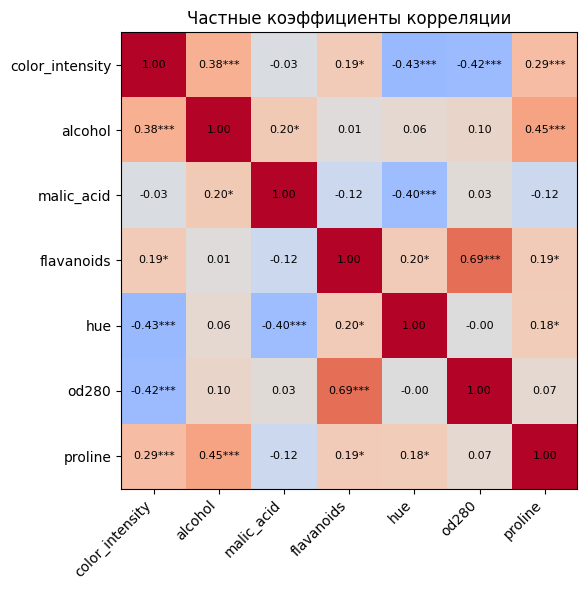

In [7]:

def partial_corr_with_p(data):
    X = data.to_numpy(dtype=float)
    n, p = X.shape
    S = np.cov(X, rowvar=False, ddof=1)
    P = np.linalg.inv(S)

    cols = list(data.columns)
    r = pd.DataFrame(np.eye(p), index=cols, columns=cols, dtype=float)
    pv = pd.DataFrame(np.zeros((p, p)), index=cols, columns=cols, dtype=float)
    lo = r.copy()
    hi = r.copy()

    c = p - 2
    dfree = n - c - 2

    for i in range(p):
        for j in range(i + 1, p):
            rr = -P[i, j] / np.sqrt(P[i, i] * P[j, j])
            tt = rr * np.sqrt(dfree / (1 - rr**2))
            pp = 2 * (1 - stats.t.cdf(abs(tt), dfree))
            z = np.arctanh(rr)
            se = 1 / np.sqrt(n - c - 3)
            zc = norm.ppf(0.975)
            lz, hz = z - zc * se, z + zc * se

            r.iloc[i, j] = r.iloc[j, i] = rr
            pv.iloc[i, j] = pv.iloc[j, i] = pp
            lo.iloc[i, j] = lo.iloc[j, i] = np.tanh(lz)
            hi.iloc[i, j] = hi.iloc[j, i] = np.tanh(hz)

    return r, pv, lo, hi

rp, pp, lo, hi = partial_corr_with_p(clean)

def make_details(r, p, lo, hi):
    rows = []
    cc = list(r.columns)
    for i in range(len(cc)):
        for j in range(i + 1, len(cc)):
            rows.append({
                'Пара': f'{cc[i]} — {cc[j]}',
                'r_partial': r.iloc[i, j],
                '95% CI': f'[{lo.iloc[i, j]:.3f}; {hi.iloc[i, j]:.3f}]',
                'p-value': p.iloc[i, j],
                'Значим': 'да' if p.iloc[i, j] < 0.05 else 'нет'
            })
    return pd.DataFrame(rows)

display(make_annot(rp, pp))
display(make_details(rp, pp, lo, hi).sort_values('p-value').head(21).round(4))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rp.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(rp.columns)))
ax.set_yticks(range(len(rp.columns)))
ax.set_xticklabels(rp.columns, rotation=45, ha='right')
ax.set_yticklabels(rp.columns)
for i in range(len(rp.columns)):
    for j in range(len(rp.columns)):
        txt = f'{rp.iloc[i, j]:.2f}'
        if i != j:
            txt += sig_stars(pp.iloc[i, j])
        ax.text(j, i, txt, ha='center', va='center', fontsize=8)
ax.set_title('Частные коэффициенты корреляции')
plt.tight_layout()
plt.show()


Частные коэффициенты корреляции позволяют точнее оценить собственный вклад факторов.

Формула имеет вид:

$$
r_{ij \cdot rest} = -\frac{p_{ij}}{\sqrt{p_{ii}p_{jj}}},
$$

где $P = R^{-1}$ — матрица, обратная корреляционной.

После учёта остальных факторов сохраняются устойчивые положительные связи `color_intensity` с `alcohol` и `proline`, а также устойчивые отрицательные связи с `hue` и `od280`. Связь с `malic_acid` практически исчезает.

Отдельного внимания заслуживает `flavanoids`: в парной корреляции связь с целевой переменной была слабой и отрицательной, тогда как частная корреляция становится положительной. Это указывает на наличие скрытой структуры совместного влияния признаков: после контроля остальных переменных проявляется собственный вклад фенольного блока.


## 6. Множественный коэффициент корреляции

Для полной системы факторов оценивается модель

$$
y = \beta_0 + \beta_1 x_1 + \dots + \beta_6 x_6 + \varepsilon
$$

и используется показатель

$$
R_{y\cdot X} = \sqrt{R^2}
$$

как множественный коэффициент корреляции.


In [8]:

full_lin = sm.OLS(clean[y_col], sm.add_constant(clean[xs])).fit()

multi_tab = pd.DataFrame({
    'Показатель': ['R^2', 'R', 'Adjusted R^2', 'F-statistic', 'p-value F'],
    'Значение': [
        full_lin.rsquared,
        np.sqrt(full_lin.rsquared),
        full_lin.rsquared_adj,
        full_lin.fvalue,
        full_lin.f_pvalue
    ]
})

display(multi_tab.round(6))
display(full_lin.summary2().tables[1].round(6))


,Показатель,Значение
0,R^2,0.641781
1,R,0.801112
2,Adjusted R^2,0.628911
3,F-statistic,49.865824
4,p-value F,0.000000


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-1.640426,2.155828,-0.760926,0.447774,-5.896615,2.615763
alcohol,0.900056,0.169797,5.300789,0.000000,0.564832,1.235281
malic_acid,-0.044475,0.111316,-0.399543,0.690004,-0.264242,0.175292
flavanoids,0.457925,0.179709,2.548150,0.011731,0.103131,0.812718
hue,-3.794424,0.610525,-6.215014,0.000000,-4.999767,-2.589081
od280,-1.404519,0.234484,-5.989829,0.000000,-1.867455,-0.941584
proline,0.001846,0.000465,3.966138,0.000108,0.000927,0.002765


Для полной модели получен множественный коэффициент корреляции **R = 0.801**. Это значение заметно превышает большинство парных коэффициентов, что соответствует теории: совокупность факторов объясняет вариацию `color_intensity` лучше, чем любой отдельный признак в изоляции.

F-критерий для модели в целом значим, следовательно, система факторов статистически связана с зависимой переменной. При этом `malic_acid` уже на данном этапе выглядит наименее устойчивым кандидатом, поскольку её индивидуальный вклад ослабевает после учёта остальных переменных.


## 7. Линейная регрессионная модель

На следующем этапе перебираются различные подмножества факторов. В рассмотрение включаются только те модели, для которых одновременно выполняются три условия:

1. коэффициенты модели статистически значимы
2. модель в целом значима
3. остатки не демонстрируют слишком сильного противоречия предположению о нормальности

Для сравнения используются `Adjusted R^2`, `AIC`, `p-value` коэффициентов и результаты проверки остатков.


,Модель,k,R^2,Adj R^2,AIC,p(F),max p(coef),JB p,Shapiro p
54,alcohol + flavanoids + hue + od280 + proline,5,0.641438,0.630767,587.240758,0.0,0.009363,0.068844,0.151432
41,alcohol + flavanoids + hue + od280,4,0.606162,0.596841,601.568623,0.0,0.000221,0.095949,0.191561
49,flavanoids + hue + od280 + proline,4,0.580551,0.570623,612.531060,0.0,0.005975,0.488705,0.561286
22,alcohol + hue + od280,3,0.572954,0.565418,613.654474,0.0,0.000008,0.050560,0.072685
34,hue + od280 + proline,3,0.561309,0.553568,618.335460,0.0,0.000000,0.502129,0.175354
13,hue + proline,2,0.487548,0.481554,643.377256,0.0,0.000000,0.112407,0.060397
14,od280 + proline,2,0.431441,0.424792,661.455420,0.0,0.000000,0.073603,0.010930
31,flavanoids + hue + od280,3,0.385639,0.374797,676.936621,0.0,0.000000,0.407207,0.243945
26,malic_acid + flavanoids + od280,3,0.277988,0.265247,705.030395,0.0,0.001820,0.095254,0.025832
9,flavanoids + hue,2,0.257344,0.248658,707.935763,0.0,0.021936,0.596339,0.176548


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-1.696780,2.145822,-0.790737,0.430213,-5.933031,2.539470
alcohol,0.886561,0.165987,5.341159,0.000000,0.558873,1.214250
flavanoids,0.467247,0.177741,2.628807,0.009363,0.116353,0.818141
hue,-3.688936,0.549106,-6.718073,0.000000,-4.772973,-2.604898
od280,-1.408946,0.233636,-6.030526,0.000000,-1.870186,-0.947706
proline,0.001871,0.000460,4.065489,0.000074,0.000962,0.002779


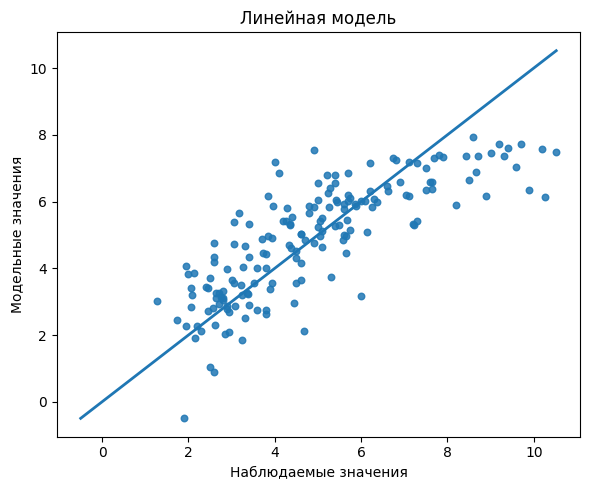

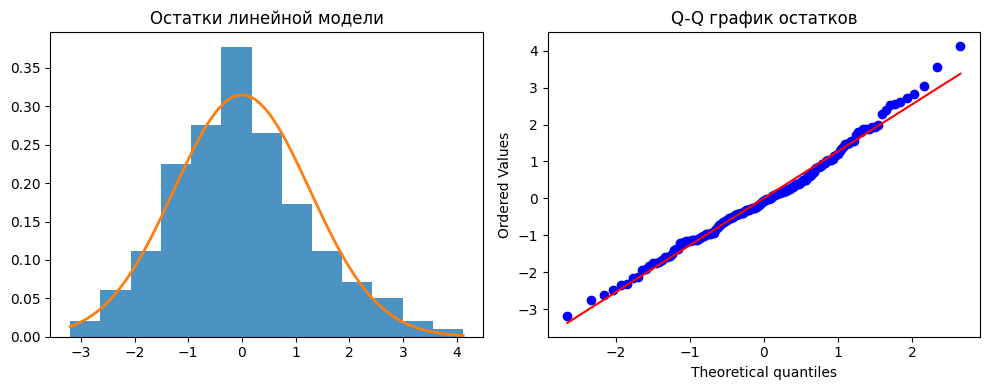

,Показатель,Значение
0,R^2,0.641438
1,Adjusted R^2,0.630767
2,AIC,587.240758
3,JB p,0.068844
4,Shapiro p,0.151432
5,RMSE,1.263710
6,MAE,0.974683


In [9]:

def search_linear(data, target, predictors):
    rows = []
    for k in range(2, len(predictors) + 1):
        for part in combinations(predictors, k):
            X = sm.add_constant(data[list(part)])
            m = sm.OLS(data[target], X).fit()
            rows.append({
                'Модель': ' + '.join(part),
                'k': k,
                'R^2': m.rsquared,
                'Adj R^2': m.rsquared_adj,
                'AIC': m.aic,
                'p(F)': m.f_pvalue,
                'max p(coef)': m.pvalues.drop('const').max(),
                'JB p': jarque_bera(m.resid).pvalue,
                'Shapiro p': shapiro(m.resid).pvalue
            })
    return pd.DataFrame(rows)

lin_pool = search_linear(clean, y_col, xs)
lin_ok = lin_pool.query('`max p(coef)` < 0.05 and `JB p` > 0.05').sort_values(['Adj R^2', 'Shapiro p'], ascending=[False, False])
display(lin_ok.head(10).round(6))

best_lin_vars = ['alcohol', 'flavanoids', 'hue', 'od280', 'proline']
lin = sm.OLS(clean[y_col], sm.add_constant(clean[best_lin_vars])).fit()
lin_fit = lin.predict(sm.add_constant(clean[best_lin_vars]))

display(lin.summary2().tables[1].round(6))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(clean[y_col], lin_fit, s=22, alpha=0.85)
lo = min(clean[y_col].min(), lin_fit.min())
hi = max(clean[y_col].max(), lin_fit.max())
ax.plot([lo, hi], [lo, hi], linewidth=2)
ax.set_xlabel('Наблюдаемые значения')
ax.set_ylabel('Модельные значения')
ax.set_title('Линейная модель')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(lin.resid, bins='auto', density=True, alpha=0.8)
xx = np.linspace(lin.resid.min(), lin.resid.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, lin.resid.mean(), lin.resid.std(ddof=1)), linewidth=2)
ax[0].set_title('Остатки линейной модели')
stats.probplot(lin.resid, dist='norm', plot=ax[1])
ax[1].set_title('Q-Q график остатков')
plt.tight_layout()
plt.show()

lin_metrics = pd.DataFrame({
    'Показатель': ['R^2', 'Adjusted R^2', 'AIC', 'JB p', 'Shapiro p', 'RMSE', 'MAE'],
    'Значение': [
        lin.rsquared,
        lin.rsquared_adj,
        lin.aic,
        jarque_bera(lin.resid).pvalue,
        shapiro(lin.resid).pvalue,
        np.sqrt(np.mean((clean[y_col] - lin_fit) ** 2)),
        np.mean(np.abs(clean[y_col] - lin_fit))
    ]
})
display(lin_metrics.round(6))


На очищенной выборке наилучшей среди линейных оказалась модель

$$
\hat y = -1.6968
+ 0.8866\,alcohol
+ 0.4672\,flavanoids
-3.6889\,hue
-1.4089\,od280
+ 0.0019\,proline
$$

Её основные характеристики таковы:

- `Adjusted R^2 = 0.631`
- все коэффициенты при факторах статистически значимы
- остатки проходят проверку на нормальность на приемлемом уровне: `JB p = 0.0688`, `Shapiro p = 0.1514`

Интерпретация коэффициентов в линейной модели остаётся прямой. При прочих равных увеличение `alcohol` на 1 единицу повышает ожидаемую `color_intensity` примерно на **0.887**, тогда как увеличение `hue` на 1 единицу уменьшает её примерно на **3.689**.

Положительный знак при `proline` согласуется с гипотезой об экстрактивности, а отрицательные коэффициенты при `hue` и `od280` соответствуют ожидаемой направленности связи. В целом линейная спецификация даёт содержательно понятный и статистически устойчивый результат.


## 8. Нелинейная степенная модель

Далее рассматривается мультипликативная форма

$$
y = a x_1^{b_1} x_2^{b_2} \dots x_k^{b_k} \varepsilon
$$

После логарифмирования она принимает линейный вид:

$$
\ln y = \ln a + b_1 \ln x_1 + \dots + b_k \ln x_k + u
$$

Главное достоинство такой записи состоит в том, что коэффициенты $b_i$ интерпретируются как эластичности.


,Модель,k,R^2 log,Adj R^2 log,R^2 original,AIC log,p(F),max p(coef),JB p,Shapiro p
54,alcohol + flavanoids + hue + od280 + proline,5,0.685175,0.675805,0.681460,20.342946,0.0,0.021393,0.090075,0.517883
23,alcohol + hue + proline,3,0.634729,0.628283,0.632682,42.203459,0.0,0.000001,0.442180,0.727505
41,alcohol + flavanoids + hue + od280,4,0.625534,0.616671,0.604884,48.529471,0.0,0.006070,0.482946,0.613802
22,alcohol + hue + od280,3,0.608422,0.601512,0.592713,54.304400,0.0,0.000421,0.294693,0.616777
24,alcohol + od280 + proline,3,0.609587,0.602698,0.570047,53.785612,0.0,0.000008,0.057153,0.237772
2,alcohol + hue,2,0.578617,0.573688,0.567018,65.068641,0.0,0.000000,0.450057,0.933311
3,alcohol + od280,2,0.560910,0.555774,0.519555,72.230845,0.0,0.000000,0.463813,0.385448
30,malic_acid + od280 + proline,3,0.512410,0.503806,0.486132,92.460718,0.0,0.002942,0.129119,0.336812
21,alcohol + flavanoids + proline,3,0.519929,0.511457,0.455049,89.756781,0.0,0.000201,0.269824,0.186663
14,od280 + proline,2,0.486298,0.480289,0.443394,99.538229,0.0,0.000000,0.061953,0.088156


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-7.422820,0.849494,-8.737926,0.000000,-9.099879,-5.745760
alcohol,2.732274,0.409570,6.671085,0.000000,1.923708,3.540841
flavanoids,0.127553,0.054915,2.322723,0.021393,0.019140,0.235967
hue,-0.679199,0.107522,-6.316861,0.000000,-0.891466,-0.466931
od280,-0.565805,0.112802,-5.015894,0.000001,-0.788498,-0.343112
proline,0.356555,0.063202,5.641503,0.000000,0.231782,0.481328


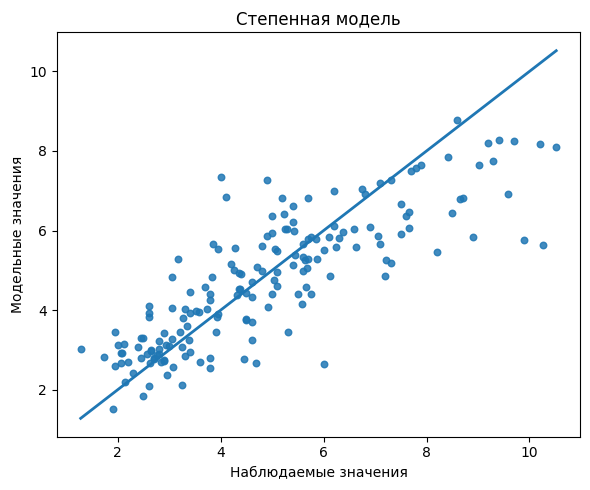

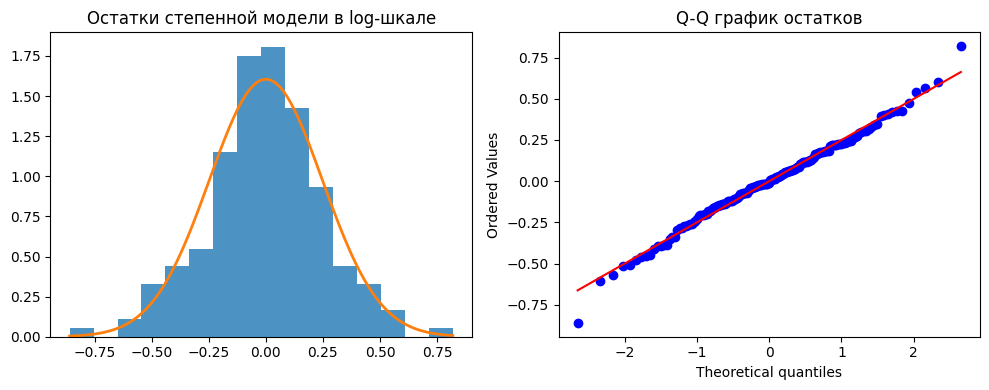

,Показатель,Значение
0,R^2 log,0.685175
1,Adjusted R^2 log,0.675805
2,R^2 в исходной шкале,0.681460
3,AIC log,20.342946
4,JB p,0.090075
5,Shapiro p,0.517883
6,RMSE,1.191099
7,MAE,0.881625


In [10]:

def search_power(data, target, predictors):
    rows = []
    yy = np.log(data[target])
    for k in range(2, len(predictors) + 1):
        for part in combinations(predictors, k):
            X = sm.add_constant(np.log(data[list(part)]))
            m = sm.OLS(yy, X).fit()
            fit = np.exp(m.predict(X))
            r2_orig = 1 - ((data[target] - fit) ** 2).sum() / ((data[target] - data[target].mean()) ** 2).sum()
            rows.append({
                'Модель': ' + '.join(part),
                'k': k,
                'R^2 log': m.rsquared,
                'Adj R^2 log': m.rsquared_adj,
                'R^2 original': r2_orig,
                'AIC log': m.aic,
                'p(F)': m.f_pvalue,
                'max p(coef)': m.pvalues.drop('const').max(),
                'JB p': jarque_bera(m.resid).pvalue,
                'Shapiro p': shapiro(m.resid).pvalue
            })
    return pd.DataFrame(rows)

pow_pool = search_power(clean, y_col, xs)
pow_ok = pow_pool.query('`max p(coef)` < 0.05 and `JB p` > 0.05').sort_values(['R^2 original', 'Adj R^2 log'], ascending=[False, False])
display(pow_ok.head(10).round(6))

best_pow_vars = ['alcohol', 'flavanoids', 'hue', 'od280', 'proline']
pow_mod = sm.OLS(np.log(clean[y_col]), sm.add_constant(np.log(clean[best_pow_vars]))).fit()
pow_fit = np.exp(pow_mod.predict(sm.add_constant(np.log(clean[best_pow_vars]))))

display(pow_mod.summary2().tables[1].round(6))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(clean[y_col], pow_fit, s=22, alpha=0.85)
lo = min(clean[y_col].min(), pow_fit.min())
hi = max(clean[y_col].max(), pow_fit.max())
ax.plot([lo, hi], [lo, hi], linewidth=2)
ax.set_xlabel('Наблюдаемые значения')
ax.set_ylabel('Модельные значения')
ax.set_title('Степенная модель')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(pow_mod.resid, bins='auto', density=True, alpha=0.8)
xx = np.linspace(pow_mod.resid.min(), pow_mod.resid.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, pow_mod.resid.mean(), pow_mod.resid.std(ddof=1)), linewidth=2)
ax[0].set_title('Остатки степенной модели в log-шкале')
stats.probplot(pow_mod.resid, dist='norm', plot=ax[1])
ax[1].set_title('Q-Q график остатков')
plt.tight_layout()
plt.show()

pow_metrics = pd.DataFrame({
    'Показатель': ['R^2 log', 'Adjusted R^2 log', 'R^2 в исходной шкале', 'AIC log', 'JB p', 'Shapiro p', 'RMSE', 'MAE'],
    'Значение': [
        pow_mod.rsquared,
        pow_mod.rsquared_adj,
        1 - ((clean[y_col] - pow_fit) ** 2).sum() / ((clean[y_col] - clean[y_col].mean()) ** 2).sum(),
        pow_mod.aic,
        jarque_bera(pow_mod.resid).pvalue,
        shapiro(pow_mod.resid).pvalue,
        np.sqrt(np.mean((clean[y_col] - pow_fit) ** 2)),
        np.mean(np.abs(clean[y_col] - pow_fit))
    ]
})
display(pow_metrics.round(6))


Наилучшая степенная модель использует тот же набор факторов, что и лучшая линейная, поэтому сравнение результатов остаётся корректным и содержательно прозрачным.

Линеаризованная запись имеет вид:

$$
\ln \hat y = -7.4228
+ 2.7323\ln(alcohol)
+ 0.1276\ln(flavanoids)
-0.6792\ln(hue)
-0.5658\ln(od280)
+ 0.3566\ln(proline)
$$

Соответствующая модель в исходной шкале записывается так:

$$
\hat y = 0.000597\cdot alcohol^{2.7323}
\cdot flavanoids^{0.1276}
\cdot hue^{-0.6792}
\cdot od280^{-0.5658}
\cdot proline^{0.3566}
$$

Коэффициенты здесь интерпретируются как эластичности:

- рост `alcohol` на 1% сопровождается увеличением `color_intensity` примерно на **2.73%**
- рост `flavanoids` на 1% связан с увеличением `color_intensity` примерно на **0.13%**
- рост `hue` на 1% соответствует снижению `color_intensity` примерно на **0.68%**
- рост `od280` на 1% соответствует снижению `color_intensity` примерно на **0.57%**
- рост `proline` на 1% сопровождается увеличением `color_intensity` примерно на **0.36%**

Для химических показателей такая интерпретация часто оказывается более естественной, чем оценка абсолютных приращений. Кроме того, по качеству подгонки степенная модель превосходит линейную: `R^2` в исходной шкале выше, а значения `RMSE` и `MAE` ниже. Остатки в логарифмической шкале также выглядят ближе к нормальным.


## 9. Итоговое сравнение моделей

В заключительном сравнении сопоставляются лучшие линейная и степенная спецификации по качеству аппроксимации на исходной шкале и по содержательной интерпретируемости коэффициентов.


In [11]:

final_cmp = pd.DataFrame({
    'Модель': ['Линейная', 'Степенная'],
    'R^2 в исходной шкале': [
        1 - ((clean[y_col] - lin_fit) ** 2).sum() / ((clean[y_col] - clean[y_col].mean()) ** 2).sum(),
        1 - ((clean[y_col] - pow_fit) ** 2).sum() / ((clean[y_col] - clean[y_col].mean()) ** 2).sum()
    ],
    'Adjusted R^2 / Adjusted R^2 log': [lin.rsquared_adj, pow_mod.rsquared_adj],
    'RMSE': [
        np.sqrt(np.mean((clean[y_col] - lin_fit) ** 2)),
        np.sqrt(np.mean((clean[y_col] - pow_fit) ** 2))
    ],
    'MAE': [
        np.mean(np.abs(clean[y_col] - lin_fit)),
        np.mean(np.abs(clean[y_col] - pow_fit))
    ],
    'JB p': [
        jarque_bera(lin.resid).pvalue,
        jarque_bera(pow_mod.resid).pvalue
    ],
    'Shapiro p': [
        shapiro(lin.resid).pvalue,
        shapiro(pow_mod.resid).pvalue
    ]
})

display(final_cmp.round(6))


,Модель,R^2 в исходной шкале,Adjusted R^2 / Adjusted R^2 log,RMSE,MAE,JB p,Shapiro p
0,Линейная,0.641438,0.630767,1.263710,0.974683,0.068844,0.151432
1,Степенная,0.681460,0.675805,1.191099,0.881625,0.090075,0.517883


## 10. Итоговый вывод

Для рассматриваемой выборки переменная `color_intensity` имеет ненормальное распределение, характеризующееся правосторонней асимметрией и умеренно выраженным верхним хвостом. Практическое правило `1.5IQR` выделило 4 верхних наблюдения, и их исключение сделало последующий анализ более устойчивым.

Корреляционный анализ показал ожидаемую структуру связей: `alcohol` и `proline` связаны с `color_intensity` положительно, `hue` и `od280` — отрицательно, а роль `malic_acid` в многомерной постановке оказывается слабой. Переменная `flavanoids` проявляет себя именно после контроля остальных факторов, что особенно отчётливо видно по частным корреляциям.

Лучшая линейная модель показала хорошие результаты, однако лучшая **степенная модель** оказалась сильнее по совокупности критериев:

- выше качество в исходной шкале: **0.681** против **0.641**
- ниже ошибки: `RMSE = 1.191` против `1.264`
- более содержательная интерпретация коэффициентов через эластичности
- остатки в log-шкале ближе к нормальному распределению

Следовательно, в рамках данного исследования предпочтение следует отдать **степенной регрессионной модели**. Она точнее описывает наблюдаемые данные и лучше соответствует содержательной логике анализа химических показателей вина.
